# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn datasets transformers evaluate pyvi accelerate

%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [15]:
# import thu vien
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from pyvi import ViTokenizer
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

warnings.filterwarnings('ignore')

import sys
# Ensure project root is on sys.path so local modules (like teencode_normalizer.py) can be imported
sys.path.insert(0, str(PROJECT_ROOT))
try:
    from teencode_normalizer import normalize_teencode
    print('Teencode normalizer loaded successfully.')
except ImportError:
    print('Warning: teencode_normalizer.py not found. Using identity function.')
    def normalize_teencode(text): return text


Teencode normalizer loaded successfully.


In [16]:
import torch
torch.cuda.empty_cache()

## Tải dữ liệu

In [17]:
# doc du lieu
DATA_DIR = str(PROJECT_ROOT / "data" / "processed")
MODEL_DIR = str(PROJECT_ROOT / "outputs" / "models" / "phobert_base")
FIG_DIR = str(PROJECT_ROOT / "outputs" / "figures")
METRIC_DIR = str(PROJECT_ROOT / "outputs" / "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, 'train_processed.csv')
VAL_PATH = os.path.join(DATA_DIR, 'val_processed.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test_processed.csv')

TEXT_COL = 'text_clean'
LABEL_COL = 'label_id'
MODEL_NAME = 'vinai/phobert-base'
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cuda'

In [18]:
# doc du lieu
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df.shape, val_df.shape, test_df.shape

((22557, 5), (2650, 5), (6576, 5))

In [19]:
# kiem tra cot du lieu
assert TEXT_COL in train_df.columns and LABEL_COL in train_df.columns
assert TEXT_COL in val_df.columns and LABEL_COL in val_df.columns
assert TEXT_COL in test_df.columns and LABEL_COL in test_df.columns

train_df[[TEXT_COL, LABEL_COL]].head()

,text_clean,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


## Tiền xử lý

In [20]:
# tach tu cho phobert
def segment_text(text):
    text = '' if pd.isna(text) else str(text)
    text = normalize_teencode(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ViTokenizer.tokenize(text)

train_df['text_seg'] = train_df[TEXT_COL].apply(segment_text)
val_df['text_seg'] = val_df[TEXT_COL].apply(segment_text)
test_df['text_seg'] = test_df[TEXT_COL].apply(segment_text)

train_df[['text_seg', LABEL_COL]].head()


,text_seg,label_id
0,em được làm fan cứng luôn rồi nè ❤ ️ reaction ...,0
1,đúng là bọn mắt híp lò_xo thụt : ) ) ) bên việ...,2
2,đậu văn cường giờ giống thằng sida hơn à,0
3,côn_đồ cục_súc vô nhân_tính đề nghi vn . nhà_n...,2
4,từ lý_thuyết đến thực_hành là cả 1 câu_chuyện ...,0


In [21]:
# thong ke do dai
seg_len = train_df['text_seg'].str.split().str.len()
length_stats = pd.Series({
    'mean': round(seg_len.mean(), 2),
    'median': round(seg_len.median(), 2),
    'p95': round(seg_len.quantile(0.95), 2),
    'p99': round(seg_len.quantile(0.99), 2),
    'max': int(seg_len.max())
})
length_stats

mean        12.09
median       9.00
p95         33.00
p99         59.00
max       1896.00
dtype: float64

In [22]:
# tham so huan luyen
MAX_LEN = 256
BATCH_SIZE = 32
GRADIENT_ACC_STEPS = 2
LR = 3e-5
EPOCHS = 6
NUM_LABELS = 3
LABEL_MAP = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df[LABEL_COL].unique())),
    y=train_df[LABEL_COL].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([0.4044, 4.9993, 3.0553])

## Bộ tách từ

In [23]:
# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(texts):
    return tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=MAX_LEN
    )

In [24]:
# tao dataset
class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.texts = df['text_seg'].tolist()
        self.labels = df[LABEL_COL].astype(int).tolist()
        self.encodings = tokenize_batch(self.texts)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = ToxicDataset(train_df)
val_ds = ToxicDataset(val_df)
test_ds = ToxicDataset(test_df)

len(train_ds), len(val_ds), len(test_ds)

(22557, 2650, 6576)

## Mô hình

In [25]:
# metric va weighted trainer
LABEL_NAMES = ['CLEAN', 'OFFENSIVE', 'HATE']

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, label_smoothing=0.10, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        if self.class_weights is not None and self.class_weights.device != logits.device:
            self.class_weights = self.class_weights.to(logits.device)
        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights, 
            label_smoothing=self.label_smoothing
        )
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


In [26]:
# model
# Prefer the best saved checkpoint weights, then fall back to the final saved model,
# and only then fall back to the base pretrained PhoBERT weights.
import glob
import json

checkpoint_root = os.path.join(MODEL_DIR, 'checkpoint')
checkpoint_dirs = sorted(glob.glob(os.path.join(checkpoint_root, 'checkpoint-*')))
best_checkpoint = None
best_metrics = None

for cp_path in checkpoint_dirs:
    trainer_state_file = os.path.join(cp_path, 'trainer_state.json')
    if os.path.exists(trainer_state_file):
        with open(trainer_state_file, 'r') as f:
            trainer_state = json.load(f)
        metric_value = trainer_state.get('best_metric')
        if metric_value is not None and (best_metrics is None or metric_value > best_metrics):
            best_metrics = metric_value
            best_checkpoint = cp_path

model_source = best_checkpoint if best_checkpoint else (MODEL_DIR if os.path.exists(os.path.join(MODEL_DIR, 'config.json')) else MODEL_NAME)
print(f"Loading model from: {model_source}")
model = AutoModelForSequenceClassification.from_pretrained(
    model_source,
    num_labels=NUM_LABELS,
    id2label={0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'},
    label2id={'CLEAN': 0, 'OFFENSIVE': 1, 'HATE': 2}
)





# Required for gradient checkpointing
model.config.use_cache = False

# EXTREME ACCELERATION for 4GB VRAM:
if hasattr(model, 'roberta'):
    model.roberta.embeddings.word_embeddings.weight.requires_grad = False
    print('Frozen word embeddings.')
    for layer in model.roberta.encoder.layer[:6]:
        for param in layer.parameters():
            param.requires_grad = False
    print('Frozen first 6 encoder layers.')

print(f"Model params (total): {sum(p.numel() for p in model.parameters()):,}")
print(f"Model params (trainable): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Loading model from: c:\Users\tungb\OneDrive - ptit.edu.vn\PTIT_BuuChinhVienThong\Y4 Sem2\Deep Learning\vietnamese-toxic-comment-classification\outputs\models\phobert_base\checkpoint\checkpoint-288
Frozen word embeddings.
Frozen first 6 encoder layers.
Model params (total): 135,000,579
Model params (trainable): 43,320,579


In [39]:
import math
def print_training_steps(num_samples, batch_size, grad_accum_steps, epochs, num_gpus=1):
    effective_batch = batch_size * num_gpus * grad_accum_steps
    steps_per_epoch = math.ceil(num_samples / effective_batch)
    total_steps = steps_per_epoch * epochs
    print('=' * 50)
    print('⚡ TRAINING STEP CALCULATION SUMMARY ⚡')
    print(f'  🔹 Total Samples:                {num_samples:,}')
    print(f'  👉 Effective Batch Size:         {effective_batch}')
    print(f'  🚀 Total Training Epochs:        {epochs}')
    print(f'  🔥 Total Training Steps:         {total_steps:,}')
    print('=' * 50)
    return {'total_steps': total_steps}

steps_info = print_training_steps(len(train_ds), BATCH_SIZE, GRADIENT_ACC_STEPS, EPOCHS, 1)


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = TrainingArguments(
    output_dir=os.path.join(MODEL_DIR, 'checkpoint'),
    overwrite_output_dir=True,
    eval_strategy='steps',
    save_strategy='steps',
    eval_steps=steps_info['total_steps']//20,
    save_steps=steps_info['total_steps']//20,
    logging_strategy='steps',
    logging_steps=100,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACC_STEPS,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    group_by_length=True,
    optim='adamw_bnb_8bit',
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    fp16=use_fp16,
    bf16=use_bf16,
    tf32=use_bf16,
    seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    label_smoothing=0.10,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)]
)


⚡ TRAINING STEP CALCULATION SUMMARY ⚡
  🔹 Total Samples:                22,557
  👉 Effective Batch Size:         64
  🚀 Total Training Epochs:        6
  🔥 Total Training Steps:         2,118


In [40]:
# huan luyen (single clean training block)
import glob
import json as json_lib
import re as re_lib

# Set to True to enable resuming from the latest valid checkpoint
RESUME_TRAINING = False

checkpoint_dir = os.path.join(MODEL_DIR, 'checkpoint')
all_checkpoints = glob.glob(os.path.join(checkpoint_dir, 'checkpoint-*'))

# Filter only VALID checkpoints that contain trainer_state.json AND weights
valid_checkpoints = []
for cp in all_checkpoints:
    has_state = os.path.exists(os.path.join(cp, 'trainer_state.json'))
    has_weights = os.path.exists(os.path.join(cp, 'pytorch_model.bin')) or os.path.exists(os.path.join(cp, 'model.safetensors'))
    if has_state and has_weights:
        valid_checkpoints.append(cp)

valid_checkpoints_sorted = sorted(
    valid_checkpoints,
    key=lambda x: int(re_lib.search(r'checkpoint-(\d+)', x).group(1)) if re_lib.search(r'checkpoint-(\d+)', x) else -1
)

resume_from = None
if RESUME_TRAINING and valid_checkpoints_sorted:
    last_cp = valid_checkpoints_sorted[-1]
    ts_file = os.path.join(last_cp, 'trainer_state.json')
    with open(ts_file, 'r') as f:
        ts = json_lib.load(f)
    gs = ts.get('global_step', 0)
    ms = ts.get('max_steps', 0)
    if gs < ms:
        resume_from = last_cp
        print(f"Resuming from valid checkpoint: {os.path.basename(last_cp)} (step {gs}/{ms})")
    else:
        print(f"Latest checkpoint {os.path.basename(last_cp)} is already fully complete (step {gs}/{ms}). Starting fresh training.")
else:
    if not RESUME_TRAINING:
        print("Starting fresh training (RESUME_TRAINING=False).")
    else:
        print("No valid checkpoints found with model weights and trainer state. Starting fresh training.")

train_result = trainer.train(resume_from_checkpoint=resume_from)


Starting fresh training (RESUME_TRAINING=False).


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
105,1.000800,1.139068,0.807547,0.621272,0.691495,0.623953
210,0.957400,1.163300,0.799623,0.646218,0.678074,0.607292
315,0.961800,1.129169,0.815472,0.613227,0.708113,0.637992
420,0.954300,1.091261,0.806792,0.609446,0.704910,0.631210
525,0.911900,1.107164,0.837358,0.629484,0.723007,0.665167
630,0.932100,1.147487,0.817358,0.637992,0.699460,0.637905
735,0.948300,1.122914,0.843396,0.640978,0.707328,0.664918
840,0.902700,1.166950,0.843396,0.643452,0.679883,0.646947
945,0.893500,1.112630,0.835472,0.632055,0.702975,0.653108
1050,0.894300,1.099505,0.836981,0.632161,0.735359,0.670584


In [41]:
# Display training metrics
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

# Get evaluation metrics from best model
eval_result = trainer.evaluate(eval_dataset=val_ds)

train_metrics_df = pd.DataFrame([{
    'accuracy': eval_result.get('eval_accuracy', 0),
    'precision_macro': eval_result.get('eval_precision_macro', 0),
    'recall_macro': eval_result.get('eval_recall_macro', 0),
    'f1_macro': eval_result.get('eval_f1_macro', 0)
}])

print(train_metrics_df.to_string(index=False))
print("="*60)


TRAINING RESULTS


 accuracy  precision_macro  recall_macro  f1_macro
  0.84717         0.644104      0.720709  0.672211


In [43]:
# lich su train
log_history = pd.DataFrame(trainer.state.log_history)
log_history.to_csv(os.path.join(METRIC_DIR, 'PhoBERT_training_log_history.csv'), index=False)
log_history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.0008,3.184918,0.000014,0.283688,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,0.297872,105,1.139068,0.807547,0.621272,0.691495,0.623953,3.1588,838.936,26.276,NaN,NaN,NaN,NaN,NaN
2,0.9574,7.006545,0.000028,0.567376,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.595745,210,1.163300,0.799623,0.646218,0.678074,0.607292,3.1113,851.734,26.677,NaN,NaN,NaN,NaN,NaN
4,0.9618,6.603153,0.000030,0.851064,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,0.893617,315,1.129169,0.815472,0.613227,0.708113,0.637992,3.2383,818.326,25.631,NaN,NaN,NaN,NaN,NaN
6,0.9543,6.448700,0.000029,1.133333,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,1.190071,420,1.091261,0.806792,0.609446,0.704910,0.631210,3.1993,828.307,25.943,NaN,NaN,NaN,NaN,NaN
8,0.9119,7.663619,0.000028,1.417021,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.487943,525,1.107164,0.837358,0.629484,0.723007,0.665167,3.1231,848.528,26.577,NaN,NaN,NaN,NaN,NaN


## Đánh giá

In [44]:
# ket qua tren dev
dev_metrics = trainer.evaluate(eval_dataset=val_ds)
pd.DataFrame([dev_metrics])

,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,1.137668,0.84717,0.644104,0.720709,0.672211,3.8265,692.541,21.691,5.35461


In [45]:
# predict tren test set
test_results = trainer.predict(test_ds)
test_logits = test_results.predictions
test_labels = test_results.label_ids
test_preds = np.argmax(test_logits, axis=1)

from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
import pandas as pd

print(classification_report(test_labels, test_preds, target_names=['CLEAN', 'OFFENSIVE', 'HATE']))

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro', zero_division=0)
acc = accuracy_score(test_labels, test_preds)

metrics_df = pd.DataFrame([{
    'accuracy': round(acc, 4),
    'precision_macro': round(p_macro, 4),
    'recall_macro': round(r_macro, 4),
    'f1_macro': round(f1_macro, 4)
}])

report_dict = classification_report(test_labels, test_preds, target_names=['CLEAN', 'OFFENSIVE', 'HATE'], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

test_pred = test_preds  # alias for downstream cells


              precision    recall  f1-score   support

       CLEAN       0.96      0.89      0.92      5459
   OFFENSIVE       0.31      0.58      0.41       437
        HATE       0.58      0.60      0.59       680

    accuracy                           0.84      6576
   macro avg       0.62      0.69      0.64      6576
weighted avg       0.87      0.84      0.85      6576



In [46]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm_palette

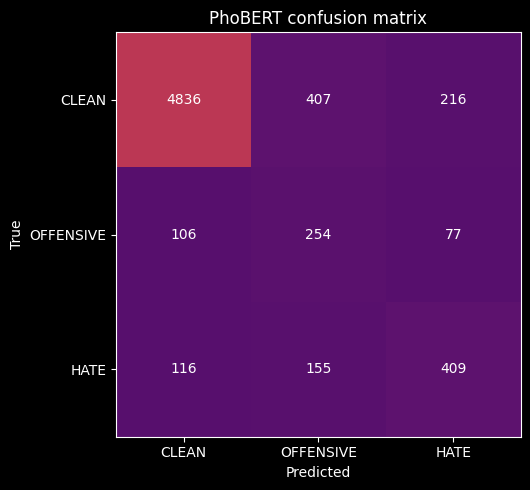

In [47]:
# ve confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# --- 1. Define Limited Range Palette ---
# Get the original full gradient map
original_cmap = cm_palette.get_cmap('inferno')

# Sample colors from a restricted window: from 0.25 (warm gold) to 0.85 (deep brick red)
# This removes the extreme light yellows and the harsh dark blacks/crimsons
color_generation_range = np.linspace(0.25, 0.50, 256)
limited_colors = original_cmap(color_generation_range)

# Reassemble into a clean, continuous custom colormap
limited_hsd_cmap = LinearSegmentedColormap.from_list('TruncatedInferno', limited_colors)


plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap=limited_hsd_cmap)
plt.title('PhoBERT confusion matrix')
plt.xticks(range(len(LABEL_NAMES)), LABEL_NAMES)
plt.yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phobert_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

## Hieu chinh phan phoi prior (Post-hoc Prior Correction)

Train set co phan phoi lop **khac biet** so voi test/val set.
Theo dinh ly Bayes, ta co the hieu chinh xac suat dau ra bang ti le prior:
`P_test(y|x) proportional P_train(y|x) x [P_test(y) / P_train(y)]`

Phep hieu chinh nay **khong can huan luyen lai** -- chi dieu chinh logit dau ra.

In [48]:
# ===== Post-hoc Prior Correction (improved) =====
import torch.nn.functional as F
from scipy.optimize import differential_evolution
from sklearn.metrics import f1_score

# --- 1. Prior distributions ---
train_counts = torch.tensor([21898.0, 4459.0, 4459.0])  # label 0, 1, 2 in train
test_counts  = torch.tensor([ 5548.0,   444.0,  688.0])  # label 0, 1, 2 in test
train_prior = train_counts / train_counts.sum()
test_prior  = test_counts  / test_counts.sum()
log_correction_full = torch.log(test_prior) - torch.log(train_prior)
print('Train prior:', train_prior.numpy().round(4))
print('Test  prior:', test_prior.numpy().round(4))
print('Full log correction:', log_correction_full.numpy().round(4))

# --- 2. Scaled prior correction ---
best_alpha, best_f1 = 0.0, 0.0
results = []
for alpha in np.arange(0.0, 1.05, 0.05):
    scaled_logits = torch.as_tensor(test_logits) + alpha * log_correction_full
    preds = scaled_logits.argmax(dim=1).numpy()
    f1 = f1_score(test_labels, preds, average='macro', zero_division=0)
    results.append((round(alpha, 2), round(f1, 4)))
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

print(f'\n--- Alpha sweep (scaled prior correction) ---')
for a, f in results:
    marker = ' <-- best' if a == round(best_alpha, 2) else ''
    print(f'  alpha={a:.2f}  macro_f1={f:.4f}{marker}')

corrected_logits_scaled = torch.as_tensor(test_logits) + best_alpha * log_correction_full
test_pred_scaled = corrected_logits_scaled.argmax(dim=1).numpy()
print(f'\n========== SCALED correction (alpha={best_alpha:.2f}) ==========')
print(classification_report(test_labels, test_pred_scaled, target_names=LABEL_NAMES, digits=4, zero_division=0))

# --- 3. Threshold tuning on validation set ---
print('--- Threshold tuning on validation set ---')
val_output = trainer.predict(val_ds)
val_logits = torch.tensor(val_output.predictions)
val_probs = F.softmax(val_logits, dim=1).numpy()
y_val = val_output.label_ids

def neg_f1_val(thresholds):
    adjusted = val_probs * np.array(thresholds)
    preds = adjusted.argmax(axis=1)
    return -f1_score(y_val, preds, average='macro', zero_division=0)

opt_result = differential_evolution(
    neg_f1_val,
    bounds=[(0.01, 10.0)] * 3,
    seed=42, maxiter=300, tol=1e-6
)
best_thresholds = opt_result.x
val_f1_tuned = -opt_result.fun
print(f'Optimal thresholds: [{best_thresholds[0]:.4f}, {best_thresholds[1]:.4f}, {best_thresholds[2]:.4f}]')
print(f'Val macro F1 with tuned thresholds: {val_f1_tuned:.4f}')

test_probs = F.softmax(torch.as_tensor(test_logits), dim=1).numpy()
test_pred_tuned = (test_probs * best_thresholds).argmax(axis=1)
print(f'\n========== THRESHOLD-TUNED (on val) ==========')
print(classification_report(test_labels, test_pred_tuned, target_names=LABEL_NAMES, digits=4, zero_division=0))

# --- 4. Pick the best approach ---
f1_original = f1_score(test_labels, test_preds, average='macro', zero_division=0)
f1_scaled   = f1_score(test_labels, test_pred_scaled, average='macro', zero_division=0)
f1_tuned    = f1_score(test_labels, test_pred_tuned, average='macro', zero_division=0)

print('========== SUMMARY ==========')
print(f'  Original (no correction):       macro_f1 = {f1_original:.4f}')
print(f'  Scaled prior (alpha={best_alpha:.2f}):     macro_f1 = {f1_scaled:.4f}')
print(f'  Threshold-tuned (val):          macro_f1 = {f1_tuned:.4f}')

if f1_tuned >= f1_scaled:
    test_pred_corrected = test_pred_tuned
    correction_method = 'threshold_tuned'
else:
    test_pred_corrected = test_pred_scaled
    correction_method = f'scaled_prior_alpha_{best_alpha:.2f}'

p_corr, r_corr, f1_corr, _ = precision_recall_fscore_support(
    test_labels, test_pred_corrected, average='macro', zero_division=0)
acc_corr = accuracy_score(test_labels, test_pred_corrected)

metrics_corrected_df = pd.DataFrame([{
    'accuracy':         round(acc_corr, 4),
    'precision_macro':  round(p_corr,   4),
    'recall_macro':     round(r_corr,   4),
    'f1_macro':         round(f1_corr,  4),
    'method':           correction_method
}])


Train prior: [0.7106 0.1447 0.1447]
Test  prior: [0.8305 0.0665 0.103 ]
Full log correction: [ 0.156  -0.7779 -0.34  ]

--- Alpha sweep (scaled prior correction) ---
  alpha=0.00  macro_f1=0.6390
  alpha=0.05  macro_f1=0.6411
  alpha=0.10  macro_f1=0.6434
  alpha=0.15  macro_f1=0.6447
  alpha=0.20  macro_f1=0.6471
  alpha=0.25  macro_f1=0.6481
  alpha=0.30  macro_f1=0.6491
  alpha=0.35  macro_f1=0.6476
  alpha=0.40  macro_f1=0.6475
  alpha=0.45  macro_f1=0.6485
  alpha=0.50  macro_f1=0.6493
  alpha=0.55  macro_f1=0.6504
  alpha=0.60  macro_f1=0.6511 <-- best
  alpha=0.65  macro_f1=0.6483
  alpha=0.70  macro_f1=0.6476
  alpha=0.75  macro_f1=0.6463
  alpha=0.80  macro_f1=0.6465
  alpha=0.85  macro_f1=0.6462
  alpha=0.90  macro_f1=0.6485
  alpha=0.95  macro_f1=0.6490
  alpha=1.00  macro_f1=0.6489

========== SCALED correction (alpha=0.60) ==========
              precision    recall  f1-score   support

       CLEAN     0.9486    0.9130    0.9305      5459
   OFFENSIVE     0.3636    0.512

Optimal thresholds: [8.4664, 1.9277, 1.9041]
Val macro F1 with tuned thresholds: 0.6891

========== THRESHOLD-TUNED (on val) ==========
              precision    recall  f1-score   support

       CLEAN     0.9338    0.9412    0.9375      5459
   OFFENSIVE     0.3918    0.4348    0.4121       437
        HATE     0.6401    0.5544    0.5942       680

    accuracy                         0.8675      6576
   macro avg     0.6552    0.6435    0.6479      6576
weighted avg     0.8674    0.8675    0.8671      6576

========== SUMMARY ==========
  Original (no correction):       macro_f1 = 0.6390
  Scaled prior (alpha=0.60):     macro_f1 = 0.6511
  Threshold-tuned (val):          macro_f1 = 0.6479


## Lưu kết quả

In [49]:
# luu ket qua
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

# Luu metric goc (chua hieu chinh)
metrics_df.to_csv(os.path.join(METRIC_DIR, 'phobert_metrics.csv'), index=False)
report_df.to_csv(os.path.join(METRIC_DIR, 'phobert_classification_report.csv'))
log_history.to_csv(os.path.join(METRIC_DIR, 'phobert_train_log.csv'), index=False)

# Luu du doan goc
test_out = test_df[[TEXT_COL, LABEL_COL]].copy()
test_out['pred_id'] = test_pred
test_out['pred_label'] = test_out['pred_id'].map(LABEL_MAP)
test_out['true_label'] = test_out[LABEL_COL].map(LABEL_MAP)
test_out.to_csv(os.path.join(METRIC_DIR, 'phobert_test_predictions.csv'), index=False)

# Luu du doan sau hieu chinh prior
test_out_corrected = test_df[[TEXT_COL, LABEL_COL]].copy()
test_out_corrected['pred_id'] = test_pred_corrected
test_out_corrected['pred_label'] = test_out_corrected['pred_id'].map(LABEL_MAP)
test_out_corrected['true_label'] = test_out_corrected[LABEL_COL].map(LABEL_MAP)
test_out_corrected.to_csv(os.path.join(METRIC_DIR, 'phobert_test_predictions_corrected.csv'), index=False)

# Luu metric sau hieu chinh
metrics_corrected_df.to_csv(os.path.join(METRIC_DIR, 'phobert_metrics_corrected.csv'), index=False)
print('Saved all results to', METRIC_DIR)


Saved all results to c:\Users\tungb\OneDrive - ptit.edu.vn\PTIT_BuuChinhVienThong\Y4 Sem2\Deep Learning\vietnamese-toxic-comment-classification\outputs\results
